In [1]:
from langchain.chat_models import init_chat_model
import markdown
from IPython.core.display import HTML

#model = "gpt-oss:20b"
model = "granite4:3b-h"
messages = [
    ("user", "Who won the 2024 US presidential election?"),
]
llm = init_chat_model(
    model_provider="ollama",
    model=model,
    # kwargs passed to the model:
    temperature=0,
    timeout=30,
    max_tokens=1000,
)

"""
# https://docs.langchain.com/oss/python/integrations/chat
!uv pip install -qU langchain-ollama
from langchain_ollama import ChatOllama
llm = ChatOllama(
    model=model,
    temperature=0)
"""

_rs = llm.invoke(messages)
_content = markdown.markdown(_rs.content)
display(HTML(_content))

In [3]:
!uv pip install -qU ddgs duckduckgo-search langchain-community

In [2]:
from langchain_community.tools import DuckDuckGoSearchResults
search = DuckDuckGoSearchResults(output_format="list", num_results=5)
search.invoke(messages[-1][1])

[{'snippet': '3 days ago - Red denotes states or congressional districts won by Republican Donald Trump ; Blue denotes those won by Democrat Kamala Harris. Counties with highest percentage of Democratic vote: ... Results by vote share in each state. Darker shades denote a higher vote share for the winning candidate.',
  'title': '2024 United States presidential election - Wikipedia',
  'link': 'https://en.wikipedia.org/wiki/2024_United_States_presidential_election'},
 {'snippet': '3 weeks ago - Elections were held in the United States on November 5, 2024. In the presidential election, former Republican President Donald Trump , seeking a non-consecutive second term, defeated the incumbent Democratic Vice President Kamala Harris. Republicans also gained control of the Senate and held ...',
  'title': '2024 United States elections - Wikipedia',
  'link': 'https://en.wikipedia.org/wiki/2024_United_States_elections'},
 {'snippet': 'December 10, 2024 - Nov. 5, 2024, 7:00 p.m. EST ... Republi

**Tool**: an external resource like function or capability that an AI model can use to perform specific tasks, such as retrieving information from a database or executing code.

Tools encapsulate a `callable function` and its `input schema`. These can be passed to _compatible chat models_, allowing the model to _decide_ whether to invoke a tool and with what arguments. In these scenarios, tool calling enables models to generate requests that conform to a specified input schema.

In [46]:
from langchain.agents import create_agent
from langchain.chat_models import init_chat_model
import markdown
from IPython.core.display import HTML

def web_search(query: str) -> str:
    """Perform a web search using DuckDuckGo."""
    from langchain_community.tools import DuckDuckGoSearchResults    
    search = DuckDuckGoSearchResults(output_format="list", num_results=3)
    return str(search.invoke(query))

#model = "gpt-oss:20b"
model = "granite4:3b-h"
messages = [{"role": "user", "content": "Who won the 2024 US presidential election?"}]
llm = init_chat_model(
    model_provider="ollama",
    model=model,
    # kwargs passed to the model:
    temperature=0,
    timeout=30,
    max_tokens=1000,
)

agent = create_agent(llm, [web_search])
# Run the agent
_rs = agent.invoke({"messages": messages})
#print(_rs)
for msg in _rs['messages']:
    _content = markdown.markdown(msg.content)
    display(HTML(_content))

In [3]:
!uv pip install -qU wikipedia

In [ ]:
from langchain_community.tools import WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper
wikipedia = WikipediaQueryRun(api_wrapper=WikipediaAPIWrapper())
wikipedia.run(messages[-1]['content'])

'Page: 2024 United States presidential election\nSummary: Presidential elections were held in the United States on November 5, 2024. The Republican Party\'s ticket—Donald Trump, who served as the 45th president of the United States from 2017 to 2021, and JD Vance, a U.S. senator from Ohio—defeated the Democratic Party\'s ticket—Kamala Harris, the incumbent U.S. vice president, and Tim Walz, the incumbent governor of Minnesota.\nThe incumbent president, Joe Biden of the Democratic Party, initially ran for re-election as its presumptive nominee, facing little opposition and easily defeating Dean Phillips, a U.S. representative, during the Democratic primaries; however, what was broadly considered a poor debate performance in June 2024 intensified concerns about his age and health, and led to calls within his party for him to leave the race. After initially declining to do so, Biden withdrew on July 21, 2024, becoming the first eligible incumbent president to withdraw since Lyndon B. John

In [1]:
from dotenv import load_dotenv
load_dotenv('../.env')

import os
os.environ["LANGCHAIN_TRACING_V2"] = "true"
os.environ["LANGCHAIN_DEBUG"] = "true"

In [ ]:

from langchain.agents import create_agent
from langchain.chat_models import init_chat_model
import markdown
from IPython.core.display import HTML
import langsmith as ls

from dotenv import load_dotenv
load_dotenv('../.env')

import os
#print(os.getenv("LANGSMITH_API_KEY"), os.getenv("LANGSMITH_PROJECT"))
os.environ["LANGCHAIN_TRACING_V2"] = "true"
os.environ["LANGCHAIN_DEBUG"] = "true"

def web_search(query: str) -> str:
    """Perform a web search using DuckDuckGo."""
    from langchain_community.tools import DuckDuckGoSearchResults    
    search = DuckDuckGoSearchResults(output_format="list", num_results=3)
    return str(search.invoke(query))

def wiki_search(query: str) -> str:
    """Perform a Wikipedia search."""
    from langchain_community.tools import WikipediaQueryRun
    from langchain_community.utilities import WikipediaAPIWrapper
    wikipedia = WikipediaQueryRun(api_wrapper=WikipediaAPIWrapper())
    return str(wikipedia.run(query))

#model = "gpt-oss:20b"
model = "granite4:3b-h"
messages = [{"role": "user", "content": "Who won the 2024 US presidential election? Output a detailed answer with tabular results."}]
llm = init_chat_model(
    model_provider="ollama",
    model=model,
    # kwargs passed to the model:
    temperature=0,
    timeout=30,
    max_tokens=1000,
)
agent = create_agent(
    llm, 
    [wiki_search, web_search], 
    system_prompt="You are a helpful assistant that uses web search and Wikipedia to answer questions. Always cite your sources with links.")
# run the agent

# explicit tracing context
#with ls.tracing_context(project_name='default', enabled=True):
_rs = agent.invoke({"messages": messages})

for msg in _rs['messages']:
    _content = markdown.markdown(msg.content)
    display(HTML(_content))

{'messages': [HumanMessage(content='Who won the 2024 US presidential election? Output a detailed answer with tabular results.', additional_kwargs={}, response_metadata={}, id='b53fb642-306d-43ef-a45d-67b45e30762a'), AIMessage(content='', additional_kwargs={}, response_metadata={'model': 'granite4:3b-h', 'created_at': '2025-12-05T07:24:55.389808299Z', 'done': True, 'done_reason': 'stop', 'total_duration': 2426156633, 'load_duration': 2042406132, 'prompt_eval_count': 248, 'prompt_eval_duration': 67713886, 'eval_count': 22, 'eval_duration': 304070081, 'logprobs': None, 'model_name': 'granite4:3b-h', 'model_provider': 'ollama'}, id='lc_run--019aed66-4162-7f03-b15e-1c08cd6d6a81-0', tool_calls=[{'name': 'wiki_search', 'args': {'query': 'United States presidential election 2024'}, 'id': '8cea1629-6204-41a8-a1f2-bf248c0d1496', 'type': 'tool_call'}], usage_metadata={'input_tokens': 248, 'output_tokens': 22, 'total_tokens': 270}), ToolMessage(content='Page: 2024 United States presidential electi

In [ ]:
from langchain.chat_models import init_chat_model
import markdown
from IPython.core.display import HTML

model = "granite4:3b-h"
messages = [
    {"role": "system", "content": "You are a helpful assistant that uses web search to answer questions. Always cite your sources with links."},
    {"role": "user", "content": "Who won the 2024 US presidential election?"},
    # simulate AI message with tool call
    {
        "role": "assistant",
        "content": "",
        "tool_calls": [{
            "id": "call_web_search_001",
            "type": "tool_call",
            "function": {
                "name": "web_search",
                "arguments": '{"query": "2024 US presidential election winner"}'
            }
        }]
    },
    # tool response
    {
        "role": "tool",
        "content": "[{'snippet': \"Trump, who lost the 2020 presidential election to Biden, ran for reelection to a nonconsecutive second term. ... the Republican Party's presidential ...\", 'title': '2024 United States presidential election - Wikipedia', 'link': 'https://en.wikipedia.org/wiki/2024_United_States_presidential_election'}, {'snippet': 'So, who won the presidential election in 2024 ? ... This means that Trump won the 2024 presidential election based on electoral votes.', 'title': 'Who Won the Presidential Election in 2024? Voting Is Over', 'link': 'https://www.distractify.com/p/who-won-the-presidential-election'}, {'snippet': 'The 2024 United States presidential election was the 60th quadrennial presidential election , held on Tuesday, November 5, 2024 .', 'title': 'Presidential Election of 2024 - 270toWin', 'link': 'https://www.270towin.com/2024-election/'}]",
        "tool_call_id": "call_web_search_001"
    }    
    ]

#model = "gpt-oss:20b"
model = "granite4:3b-h"
llm = init_chat_model(
    model_provider="ollama",
    model=model,
    # kwargs passed to the model:
    temperature=0,
    timeout=30,
    max_tokens=1000,
)

_rs = llm.invoke(messages)
_content = markdown.markdown(_rs.content)
display(HTML(_content))


How LLMs Use Tools

📚 CONCEPT:
When you use tools with an LLM, there's a 'hidden' layer of communication.
The model receives TWO inputs:
  1. user message (the question)
  2. tool schemas (JSON descriptions of available functions)

The LLM analyzes these schemas to:
  • Decide WHICH tool(s) to use
  • Extract/transform the user query into the correct parameter format
  • Generate a 'tool call' request with the function name and arguments

--------------------------------------------------------------------------------
TOOL SCHEMAS SENT TO THE MODEL
--------------------------------------------------------------------------------

🔧 Tool: wiki_search
Description: Perform a Wikipedia search.

Full Schema (what the LLM sees):
{
  "type": "function",
  "function": {
    "name": "wiki_search",
    "description": "Perform a Wikipedia search.",
    "parameters": {
      "properties": {
        "query": {
          "type": "string"
        }
      },
      "required": [
        "query"
      ],

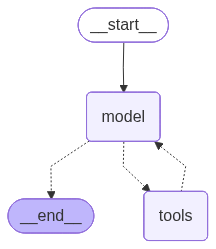

In [13]:
from langchain_core.utils.function_calling import convert_to_openai_tool
import json

print("=" * 80)
print("How LLMs Use Tools")
print("=" * 80)

print("\n📚 CONCEPT:")
print("When you use tools with an LLM, there's a 'hidden' layer of communication.")
print("The model receives TWO inputs:")
print("  1. user message (the question)")
print("  2. tool schemas (JSON descriptions of available functions)")
print("\nThe LLM analyzes these schemas to:")
print("  • Decide WHICH tool(s) to use")
print("  • Extract/transform the user query into the correct parameter format")
print("  • Generate a 'tool call' request with the function name and arguments\n")

print("-" * 80)
print("TOOL SCHEMAS SENT TO THE MODEL")
print("-" * 80)

tools = [wiki_search, web_search]
for t in tools:
    tool_schema = convert_to_openai_tool(t)
    
    print(f"\n🔧 Tool: {tool_schema['function']['name']}")
    print(f"Description: {tool_schema['function']['description']}")
    print(f"\nFull Schema (what the LLM sees):")
    print(json.dumps(tool_schema, indent=2))
    print("-" * 40)

print("\n📋 EXAMPLE WORKFLOW:")
print("1. User asks: 'Who won the 2024 US presidential election?'")
print("2. LLM receives the question + the tool schemas above")
print("3. LLM decides: 'I should use web_search or wiki_search'")
print("4. LLM generates tool call: web_search(query='2024 US presidential election winner')")
print("5. Your code executes the function and returns results")
print("6. LLM receives results and formulates final answer")

print("\n" + "=" * 80)
print("AGENT EXECUTION GRAPH")
print("=" * 80)
from IPython.display import Image

_graph = agent.get_graph().draw_mermaid_png()
display(Image(_graph))

In [ ]:
import json
import requests

print("=" * 80)
print("DIRECT API CALL: How Tool Calling Works Under the Hood")
print("=" * 80)

# Define the tool schemas (from LangChain)
tools = [
    {
        "type": "function",
        "function": {
            "name": "wiki_search",
            "description": "Perform a Wikipedia search.",
            "parameters": {
                "properties": {
                    "query": {"type": "string"}
                },
                "required": ["query"],
                "type": "object"
            }
        }
    },
    {
        "type": "function",
        "function": {
            "name": "web_search",
            "description": "Perform a web search using DuckDuckGo.",
            "parameters": {
                "properties": {
                    "query": {"type": "string"}
                },
                "required": ["query"],
                "type": "object"
            }
        }
    }
]

# The user query
user_message = "Who won the 2024 US presidential election?"

print("\n🔧 METHOD 1: Using curl command")
print("-" * 80)

curl_command = f"""curl http://localhost:11434/api/chat -d '{json.dumps({
    "model": "granite4:3b-h",
    "messages": [
        {
            "role": "user",
            "content": user_message
        }
    ],
    "tools": tools,
    "stream": False
}, indent=2)}'"""

print(curl_command)

print("\n\n🐍 METHOD 2: Using Python requests")
print("-" * 80)

# Prepare the request
url = "http://localhost:11434/api/chat"
payload = {
    "model": "granite4:3b-h",
    "messages": [
        {
            "role": "user",
            "content": user_message
        }
    ],
    "tools": tools,
    "stream": False
}

print("Request payload:")
print(json.dumps(payload, indent=2))

print("\n" + "-" * 80)
print("Making actual API call...")
print("-" * 80)

try:
    response = requests.post(url, json=payload)
    response_data = response.json()
    
    print("\n✅ RESPONSE:")
    print(json.dumps(response_data, indent=2))
    
    # Check if model wants to use tools
    if "message" in response_data:
        msg = response_data["message"]
        
        if "tool_calls" in msg and msg["tool_calls"]:
            print("\n" + "=" * 80)
            print("🎯 MODEL DECIDED TO USE TOOLS!")
            print("=" * 80)
            
            for tool_call in msg["tool_calls"]:
                func = tool_call["function"]
                print(f"\n🔧 Tool: {func['name']}")
                print(f"📝 Arguments: {func['arguments']}")
                
                # Parse arguments
                args = json.loads(func["arguments"]) if isinstance(func["arguments"], str) else func["arguments"]
                print(f"🔍 Extracted query: '{args.get('query', '')}'")
                
            print("\n💡 KEY INSIGHT:")
            print("The LLM transformed the user's question into a structured tool call!")
            print(f"Original: '{user_message}'")
            print(f"Transformed: {func['name']}(query='{args.get('query', '')}')")
                
        else:
            print("\n⚠️ Model responded without using tools")
            print(f"Content: {msg.get('content', 'N/A')}")
            
except Exception as e:
    print(f"\n❌ Error: {e}")
    print("\nMake sure Ollama is running: ollama serve")

print("\n" + "=" * 80)
print("📚 EXPLANATION")
print("=" * 80)
print("""
When you send tools to Ollama/Open AI-compatible API:

1. The 'tools' array is passed alongside the messages
2. The LLM sees both the user query AND the tool schemas
3. If the LLM decides a tool is needed, it responds with:
   - role: "assistant"
   - tool_calls: [{function: {name: "...", arguments: {...}}}]
   
4. Application should then:
   - Execute the actual function (web_search or wiki_search)
   - Send the result back in a new message with role: "tool"
   - Let the LLM generate the final answer
""")

DIRECT API CALL: How Tool Calling Works Under the Hood

🔧 METHOD 1: Using curl command
--------------------------------------------------------------------------------
curl http://localhost:11434/api/chat -d '{
  "model": "granite4:3b-h",
  "messages": [
    {
      "role": "user",
      "content": "Who won the 2024 US presidential election?"
    }
  ],
  "tools": [
    {
      "type": "function",
      "function": {
        "name": "wiki_search",
        "description": "Perform a Wikipedia search.",
        "parameters": {
          "properties": {
            "query": {
              "type": "string"
            }
          },
          "required": [
            "query"
          ],
          "type": "object"
        }
      }
    },
    {
      "type": "function",
      "function": {
        "name": "web_search",
        "description": "Perform a web search using DuckDuckGo.",
        "parameters": {
          "properties": {
            "query": {
              "type": "string"
   

[http request details](../.http/tool_selection.http)